# Customer Segmentation System Using RFM Analysis
## Objective

Experimenting Customer Segmentation using RFM Analysis

Dataset : https://www.kaggle.com/datasets/emrhn1031/online-retail-dataset?resource=download

Author : Sai Lalith Sistla

In [29]:
# import library
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import datetime as dt

#For Data  Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#For Machine Learning Algorithm
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from kneed import KneeLocator

In [30]:
df = pd.read_csv(r'./datasets/Online_Retail_Dataset kaggle.csv')
df.head(5)

,Unnamed: 0,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,1,536365.0,71053.0,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,2,536365.0,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,3,536365.0,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,4,536365.0,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  float64
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 37.2+ MB


### Data Cleansing and pre-processing

- DUplicate Data 
- Null value treatment
- Range / outlier treatment

In [32]:
# Cleanse all string columns of spaces
string_columns = df.select_dtypes(include=['object', 'string']).columns
df[string_columns] = df[string_columns].apply(lambda x: x.str.strip())

#check and clean duplicate data
print("Duplicates Before : ", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates After : ", df.duplicated().sum())

Duplicates Before :  0
Duplicates After :  0


In [33]:
df.isnull().sum()

Unnamed: 0          0
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [34]:
# CustomerID helps to bin the treansactions and as such null in the columns will not be useful for analysis
df= df.dropna(subset=['CustomerID'])

In [35]:
df.describe()

,Unnamed: 0,Quantity,UnitPrice,CustomerID
count,406829.000000,406829.000000,406829.000000,406829.000000
mean,278048.159318,12.061303,3.460471,15287.690570
std,152744.019884,248.693370,69.315162,1713.600303
min,0.000000,-80995.000000,0.000000,12346.000000
25%,147749.000000,2.000000,1.250000,13953.000000
50%,284435.000000,5.000000,1.950000,15152.000000
75%,409528.000000,12.000000,3.750000,16791.000000
max,541908.000000,80995.000000,38970.000000,18287.000000


In [36]:
df=df[(df['Quantity']>0) & (df['UnitPrice']>0)]
df.describe()

,Unnamed: 0,Quantity,UnitPrice,CustomerID
count,397884.000000,397884.000000,397884.000000,397884.000000
mean,278462.993893,12.988238,3.116488,15294.423453
std,152770.852038,179.331775,22.097877,1713.141560
min,0.000000,1.000000,0.001000,12346.000000
25%,148333.750000,2.000000,1.250000,13969.000000
50%,284902.500000,6.000000,1.950000,15159.000000
75%,410074.250000,12.000000,3.750000,16795.000000
max,541908.000000,80995.000000,8142.750000,18287.000000


In [37]:
df.groupby('Description').agg(
    count=('InvoiceNo', 'count'), 
    distinct_count=('InvoiceNo', lambda x: x.nunique())
).sort_values(by='distinct_count', ascending=False).head(20)

,count,distinct_count
Description,,
WHITE HANGING HEART T-LIGHT HOLDER,2028,1971
REGENCY CAKESTAND 3 TIER,1723,1703
JUMBO BAG RED RETROSPOT,1618,1600
PARTY BUNTING,1396,1379
ASSORTED COLOUR BIRD ORNAMENT,1408,1375
LUNCH BAG RED RETROSPOT,1316,1288
SET OF 3 CAKE TINS PANTRY DESIGN,1159,1146
POSTAGE,1099,1099
LUNCH BAG BLACK SKULL.,1105,1052


In [38]:
# Removing "Postage" as it is not an item for sale
print(df.shape)
df = df[(df['Description'] != 'POSTAGE')]
print(df.shape)

(397884, 9)
(396785, 9)


In [39]:
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])
df['order_date'] = [d.date() for d in df['InvoiceDate']]
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_time'] = [d.time() for d in df['InvoiceDate']]

df.head()

,Unnamed: 0,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,order_date,order_time
0,0,536365.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,08:26:00
1,1,536365.0,71053.0,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
2,2,536365.0,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,08:26:00
3,3,536365.0,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00
4,4,536365.0,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00


In [40]:
#New Total Sum Column  
df['TotalSum'] = df['UnitPrice']* df['Quantity']

#Data preparation steps
print('Min Invoice Date:', df.order_date.dt.date.min(),'\nmax Invoice Date:', df.order_date.dt.date.max())

Min Invoice Date: 2010-12-01 
max Invoice Date: 2011-12-09


In [41]:
df.head(3)

,Unnamed: 0,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,order_date,order_time,TotalSum
0,0,536365.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,15.30
1,1,536365.0,71053.0,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,20.34
2,2,536365.0,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,08:26:00,22.00


In [42]:
snapshot_date = df['order_date'].max() + dt.timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 00:00:00')

#### Observation: 

- The last day of purchase in total is 09 DEC, 2011. To calculate the day periods, let's set one day after the last one,or 10 DEC as a snapshot_date. We will count the diff days with snapshot_date.

### Calculate RFM Metrics

In [43]:
rfm = df.groupby(['CustomerID']).agg({
    'order_date': lambda x : (snapshot_date - x.max()).days,
    'InvoiceNo':'count',
    'TotalSum': 'sum'
})

rfm.rename(columns={'order_date':'Recency', 'InvoiceNo':'Frequency', 'TotalSum':'MonetaryValue'},inplace= True)

#Final RFM values
rfm.head()

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346.0,326,1,77183.60
12347.0,3,182,4310.00
12348.0,76,27,1437.24
12349.0,19,72,1457.55
12350.0,311,16,294.40


### RFM Analysis
RFM analysis has support for the marketing proverb that “80% of business comes from 20% of the customer”

Segment Range	RFM Score Range
        Gold	>9
        Silver	>5 and <=9
        Bronze	>=5

In [44]:
#Building RFM segments
r_labels =range(4,0,-1)
f_labels=range(1,5)
m_labels=range(1,5)
r_quartiles = pd.qcut(rfm['Recency'], q=4, labels = r_labels)
f_quartiles = pd.qcut(rfm['Frequency'],q=4, labels = f_labels)
m_quartiles = pd.qcut(rfm['MonetaryValue'],q=4,labels = m_labels)
rfm = rfm.assign(R=r_quartiles,F=f_quartiles,M=m_quartiles)
# Build RFM Segment and RFM Score
def add_rfm(x) : return str(x['R']) + str(x['F']) + str(x['M'])
rfm['RFM_Segment'] = rfm.apply(add_rfm,axis=1 )
rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)
rfm.head()

,Recency,Frequency,MonetaryValue,R,F,M,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,1.01.04.0,6
12347.0,3,182,4310.00,4,4,4,4.04.04.0,12
12348.0,76,27,1437.24,2,2,3,2.02.03.0,7
12349.0,19,72,1457.55,3,3,3,3.03.03.0,9
12350.0,311,16,294.40,1,1,1,1.01.01.0,3


In [45]:
def segments(df):
    if df['RFM_Score'] > 9 :
        return 'Gold'
    elif (df['RFM_Score'] > 5) and (df['RFM_Score'] <= 9 ):
        return 'Silver'
    else:
        return 'Bronze'
rfm['General_Segment'] = rfm.apply(segments,axis=1)
rfm.groupby('General_Segment').agg({'Recency':'mean', 'Frequency':'mean', 'MonetaryValue':['mean','count']}).round(1)

Recency Frequency MonetaryValue      
                   mean      mean          mean count
General_Segment                                      
Bronze            192.2      15.1         264.7  1291
Gold               20.4     228.7        5220.3  1259
Silver             72.7      50.0        1073.6  1788

In [46]:
MergedRFM=pd.merge(df,rfm,on='CustomerID')
MergedRFM

,Unnamed: 0,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,order_date,...,TotalSum,Recency,Frequency,MonetaryValue,R,F,M,RFM_Segment,RFM_Score,General_Segment
0,0,536365.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,...,15.30,373,297,5391.21,1,4,4,1.04.04.0,9,Silver
1,1,536365.0,71053.0,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,...,20.34,373,297,5391.21,1,4,4,1.04.04.0,9,Silver
2,2,536365.0,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,...,22.00,373,297,5391.21,1,4,4,1.04.04.0,9,Silver
3,3,536365.0,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,...,20.34,373,297,5391.21,1,4,4,1.04.04.0,9,Silver
4,4,536365.0,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,...,20.34,373,297,5391.21,1,4,4,1.04.04.0,9,Silver
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396780,541904,581587.0,22613.0,PACK OF 20 SPACEBOY NAPKINS,12.0,2011-12-09 12:50:00,0.85,12680.0,France,2011-12-09,...,10.20,1,49,790.81,4,3,3,4.03.03.0,10,Gold
396781,541905,581587.0,22899.0,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680.0,France,2011-12-09,...,12.60,1,49,790.81,4,3,3,4.03.03.0,10,Gold
396782,541906,581587.0,23254.0,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-09,...,16.60,1,49,790.81,4,3,3,4.03.03.0,10,Gold
396783,541907,581587.0,23255.0,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-09,...,16.60,1,49,790.81,4,3,3,4.03.03.0,10,Gold


In [47]:
Bronze_seg = MergedRFM[MergedRFM.General_Segment == 'Bronze']
Silver_seg = MergedRFM[MergedRFM.General_Segment == 'Silver']
Gold_seg = MergedRFM[MergedRFM.General_Segment == 'Gold']

### Data Pre-Processing for K-means Clustering
We must check these Key k-means assumptions before we implement our K-means clustering Mode

- Symmetric distribution of variables (not skewed)
- Variables with same average values
- Variables with same variance

In [48]:
def find_skewness(df, columns_to_check):
    for col_name in columns_to_check:
        # Calculate skewness
        skewness = skew(df[col_name])
        # Skewness interpretation
        if -0.5 <= skewness <= 0.5:
            interpretation = "The data is approximately symmetric. No fix needed."
        elif 0.5 < skewness <= 1:
            interpretation = "The data is moderately positively skewed. Consider applying a transformation if needed."
        elif skewness > 1:
            interpretation = "The data is highly positively skewed. A fix is recommended."
        elif -1 <= skewness < -0.5:
            interpretation = "The data is moderately negatively skewed. Consider applying a transformation if needed."
        else:
            interpretation = "The data is highly negatively skewed. A fix is recommended."
        print(f"Column name : {col_name} \t Skewness: {skewness:.2f} \t {interpretation}")
        
def plot_skewness(df, columns_to_check):
    # Set style
    plt.style.use('fivethirtyeight')

    # Create the subplots
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), constrained_layout=True)

    # Plot Recency
    sns.histplot(rfm.Recency, kde=True, ax=axes[0], label='Recency')
    axes[0].set_title('Recency Distribution')

    # Plot Frequency
    sns.histplot(rfm.Frequency, kde=True, ax=axes[1], label='Frequency')
    axes[1].set_title('Frequency Distribution')

    # Plot Monetary Value
    sns.histplot(rfm.MonetaryValue, kde=True, ax=axes[2], label='Monetary Value')
    axes[2].set_title('Monetary Value Distribution')

    # Show the plots
    plt.show()

In [49]:
rfm_select = rfm[['Recency','Frequency','MonetaryValue']]
print(rfm_select.describe())

           Recency    Frequency  MonetaryValue
count  4338.000000  4338.000000    4338.000000
mean     93.089673    91.467266    2036.331015
std     100.014839   228.669221    8960.024748
min       1.000000     1.000000       3.750000
25%      18.000000    17.000000     306.210000
50%      51.000000    41.000000     668.125000
75%     143.000000   100.000000    1644.550000
max     374.000000  7847.000000  279138.020000


#### Observations : 

From this table, we find this problem: Mean and Variance are not Equal

Solution: Scaling variables by using a scaler from scikit-learn library

## Plot the distribution of RFM values

Column name : Recency 	 Skewness: 1.24 	 The data is highly positively skewed. A fix is recommended.
Column name : Frequency 	 Skewness: 18.12 	 The data is highly positively skewed. A fix is recommended.
Column name : MonetaryValue 	 Skewness: 19.38 	 The data is highly positively skewed. A fix is recommended.


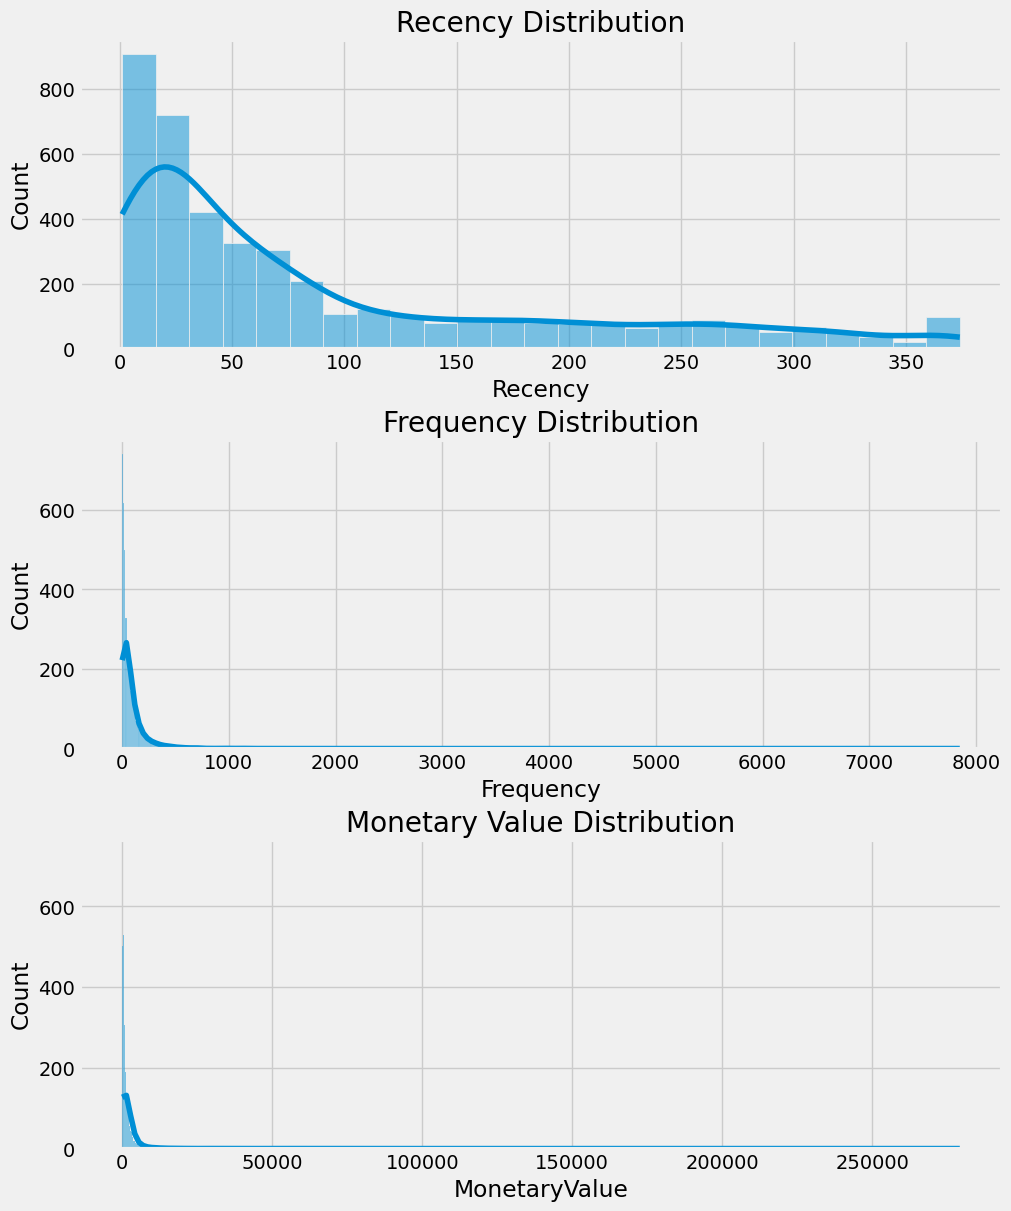

In [50]:
find_skewness(rfm, ['Recency','Frequency','MonetaryValue'])
plot_skewness(rfm, ['Recency','Frequency','MonetaryValue'])

#### Observations : 

Also, there is another Problem: Unsymmetric distribution of variables (Data skewed)

Solution: Logarithmic transformation (positive values only) will manage skewness


We use these Sequence of structuring pre-processing steps:

1. Unskew the data – log transformation

2. Standardize to the same average values

3. Scale to the same standard deviation

4. Store as a separate array to be used for clustering

Why the Sequence Matters?

Log transformation only works with positive data
Normalization forces data to have negative values and log will not work

### Unskew the data with log transformation

In [51]:
rfm_log = rfm[['Recency', 'Frequency', 'MonetaryValue']].apply(np.log, axis = 1).round(3)

Column name : Recency 	 Skewness: -0.47 	 The data is approximately symmetric. No fix needed.
Column name : Frequency 	 Skewness: -0.22 	 The data is approximately symmetric. No fix needed.
Column name : MonetaryValue 	 Skewness: 0.38 	 The data is approximately symmetric. No fix needed.


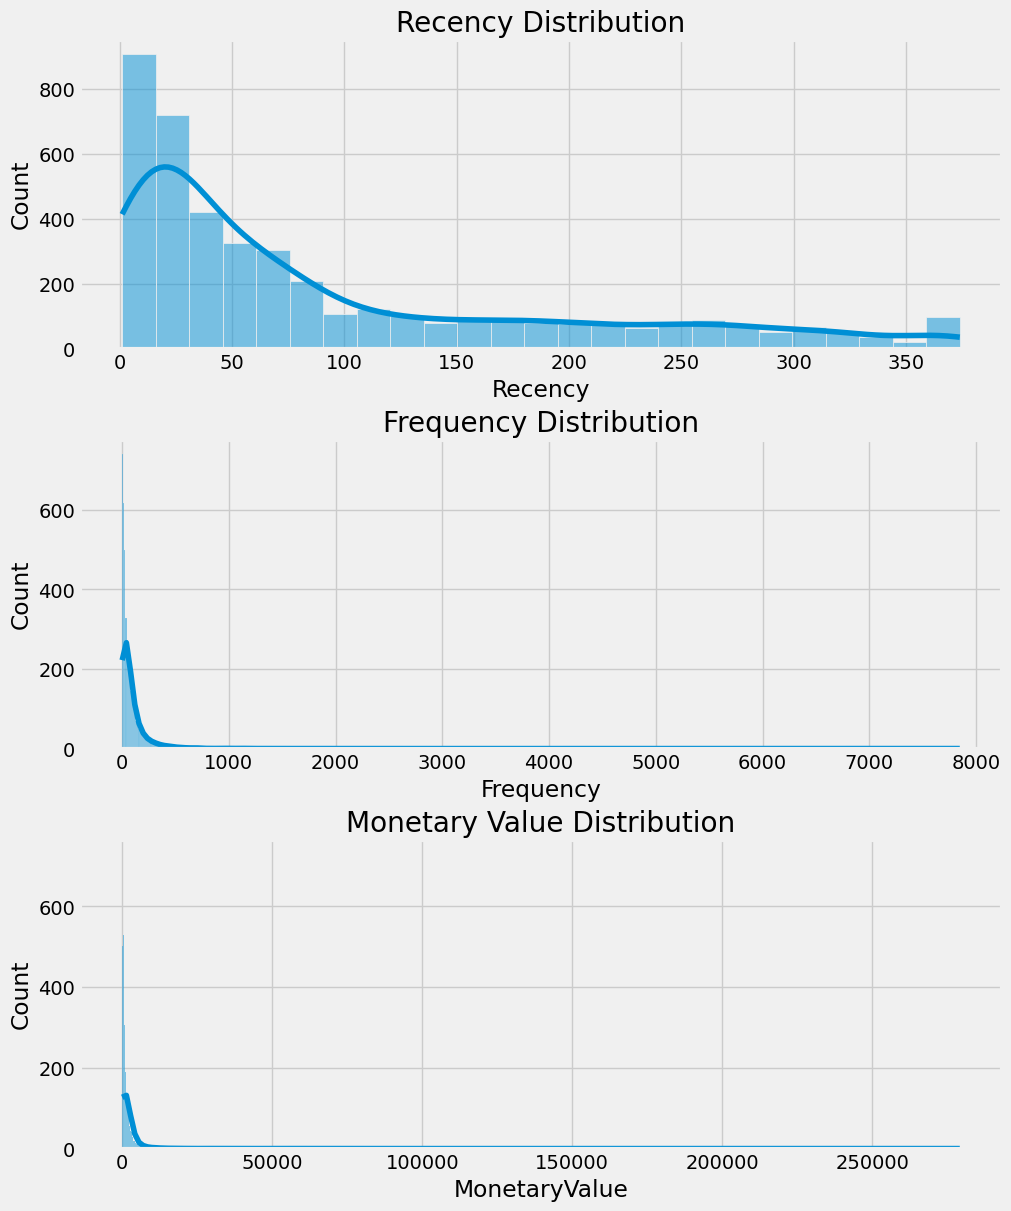

In [52]:
find_skewness(rfm_log, ['Recency','Frequency','MonetaryValue'])
plot_skewness(rfm_log, ['Recency','Frequency','MonetaryValue'])

In [53]:
#Normalize the variables with StandardScaler

scaler = StandardScaler()
scaler.fit(rfm_log)

#Store it separately for clustering
rfm_normalized= scaler.transform(rfm_log)

### Implementation of K-Means Clustering

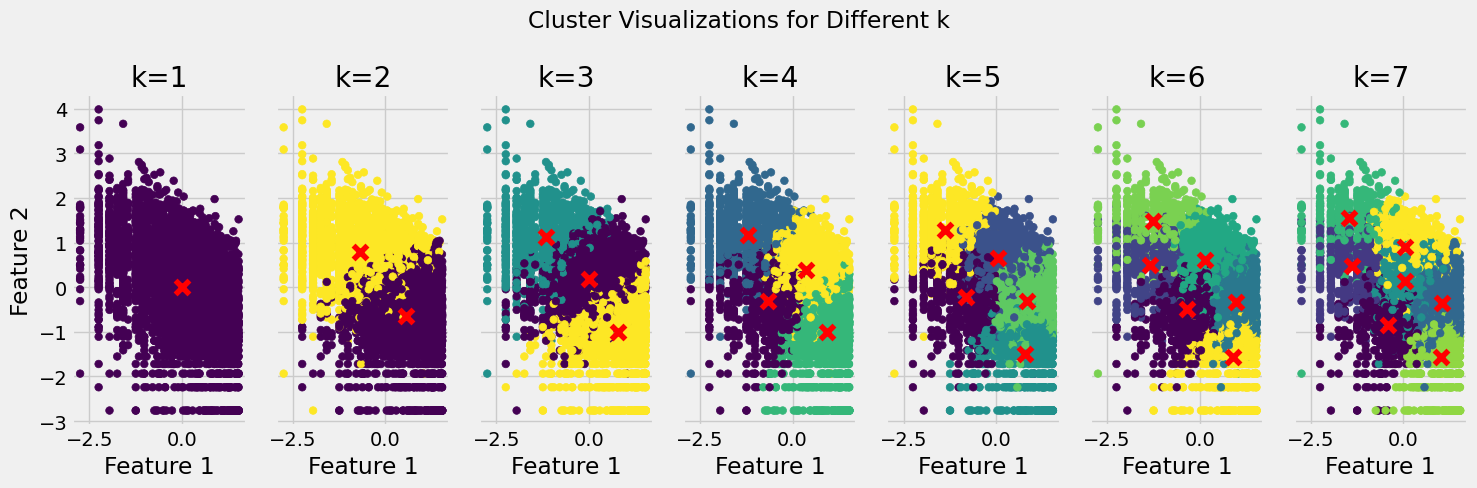

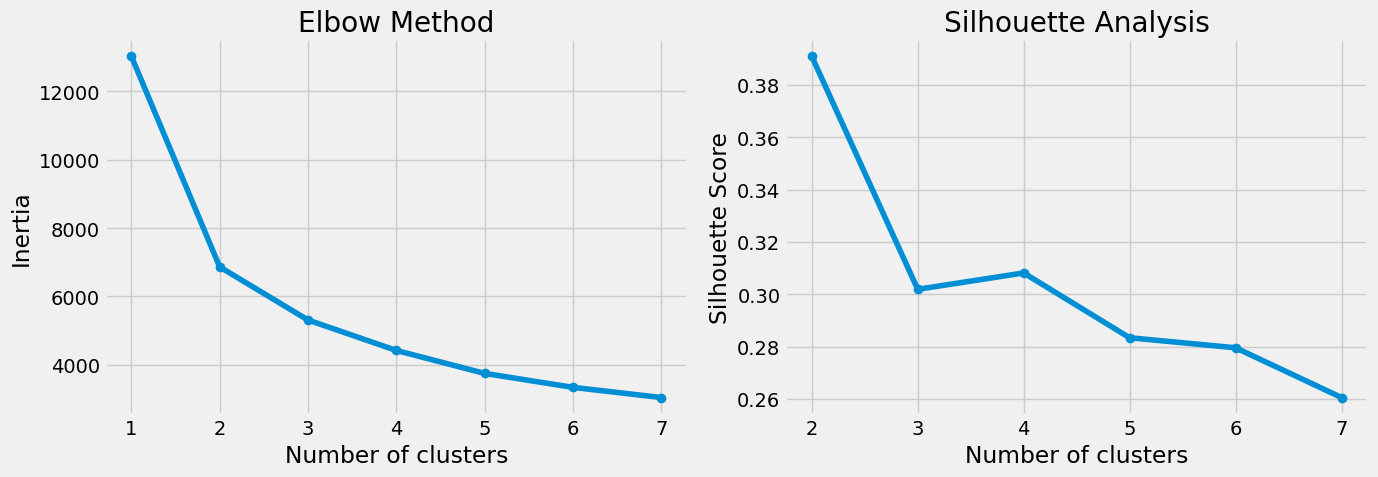

In [54]:
# Choosing no of Clusters
#First : Get the Best KMeans 
cluster_range = range(1,8)

# Plot clusters for different k  ++ Elbow method ++ silhouette_scores method
fig, axes = plt.subplots(1, len(cluster_range), figsize=(15, 5), sharey=True)
inertia = []
silhouette_scores = []

for i, k in enumerate(cluster_range):
    # Create a KMeans clusters
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(rfm_normalized)
    inertia.append(km.inertia_)
    if k>1:
        silhouette_scores.append(silhouette_score(rfm_normalized, km.labels_, sample_size=1000, random_state=42))
    else:
        silhouette_scores.append(None)
    y_kmeans = km.fit_predict(rfm_normalized)

    axes[i].scatter(rfm_normalized[:, 0], rfm_normalized[:, 1], c=y_kmeans, s=30, cmap='viridis')
    axes[i].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c='red', s=100, marker='x')
    axes[i].set_title(f'k={k}')
    axes[i].set_xlabel('Feature 1')
    if i == 0:
        axes[i].set_ylabel('Feature 2')

plt.suptitle('Cluster Visualizations for Different k')
plt.tight_layout()
plt.show()

    
# Plot Elbow Method
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(cluster_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title('Silhouette Analysis')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [55]:
# Assuming 'cluster_range' and 'inertia' are defined
knee_locator = KneeLocator(cluster_range, inertia, curve="convex", direction="decreasing")
optimal_k = knee_locator.knee
print(f"Optimal number of clusters (Knee locator): {optimal_k}")


# Calculate the first and second derivatives of inertia
first_derivative = np.diff(inertia)
second_derivative = np.diff(first_derivative)

# Find the index of the maximum change in the second derivative
optimal_k_index = np.argmin(second_derivative) + 1  # +1 because np.diff reduces dimensions by 1
optimal_k = cluster_range[optimal_k_index]

print(f"Optimal number of clusters (2nd derivative): {optimal_k}")

Optimal number of clusters (Knee locator): 2
Optimal number of clusters (2nd derivative): 6


Observations : 

- it's a close call, but available options for cluster sizes are (2,3,5,6)
- Further call can be taken using busines knowledge